<a href="https://colab.research.google.com/github/dmitry-grigorev/disser_code/blob/main/paper_1_text_embeddings/disser_studying_embeddings_layer_pooler_ver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip '/content/ruenRoSBERTa_finetuned_layer_pooler_embeddings_v2.zip'

Archive:  /content/ruenRoSBERTa_finetuned_layer_pooler_embeddings_v2.zip
  inflating: ruenRoSBERTa_finetuned_layer_pooler_embeddings_v2/val_index.npy  
  inflating: ruenRoSBERTa_finetuned_layer_pooler_embeddings_v2/val_embeddings.npy  
  inflating: ruenRoSBERTa_finetuned_layer_pooler_embeddings_v2/test_embeddings.npy  
  inflating: ruenRoSBERTa_finetuned_layer_pooler_embeddings_v2/train_full_index.npy  
  inflating: ruenRoSBERTa_finetuned_layer_pooler_embeddings_v2/train_full_embeddings.npy  
  inflating: ruenRoSBERTa_finetuned_layer_pooler_embeddings_v2/train_embeddings.npy  
  inflating: ruenRoSBERTa_finetuned_layer_pooler_embeddings_v2/train_index.npy  
  inflating: ruenRoSBERTa_finetuned_layer_pooler_embeddings_v2/test_index.npy  


In [ ]:
!mkdir stage1
!mkdir stage2
!unzip "/content/model_and_metrics_embeddings_layer_pooler_finetuning_stage2.zip" -d stage2
#!unzip /content/model_and_metrics_embeddings_layer_pooler_finetuning_stage1.zip -d stage1


Archive:  /content/model_and_metrics_embeddings_layer_pooler_finetuning_stage2.zip
  inflating: stage2/metrics_1/train_losses.txt  
  inflating: stage2/metrics_1/val_losses.txt  
  inflating: stage2/metrics_1/train_rmses.txt  
  inflating: stage2/metrics_1/val_rmses.txt  
  inflating: stage2/metrics_finetuning_head_2/train_losses.txt  
  inflating: stage2/metrics_finetuning_head_2/val_losses.txt  
  inflating: stage2/metrics_finetuning_head_2/train_rmses.txt  
  inflating: stage2/metrics_finetuning_head_2/val_rmses.txt  
  inflating: stage2/model_checkpoints_1/best_checkpoint_pooler.pt  
  inflating: stage2/model_checkpoints_1/best_checkpoint.pt  
  inflating: stage2/model_checkpoints_1/best_checkpoint_layer23.pt  
  inflating: stage2/model_checkpoints_finetuning_head_2/best_checkpoint_pooler.pt  
  inflating: stage2/model_checkpoints_finetuning_head_2/best_checkpoint.pt  


In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import torch.nn as nn
from collections import OrderedDict
# простая нейронная сеть, на вход которой подаются эмбеддинги
class RoSBERTRegressor_2layerhead(nn.Module):
    def __init__(self):
        super().__init__()

        # Store the pre-trained SBERT model
        self.hidden_layer_neurons = 256
        self.activation = nn.Sigmoid()
        self.regression_head = nn.Sequential(
                      OrderedDict([
                          ('regression_head1', nn.Linear(1024, self.hidden_layer_neurons)),
                          ('aciv1', self.activation),
                          ('regression_head2', nn.Linear(self.hidden_layer_neurons, 1)),
                      ])
                  )

    def forward(self, x):
        embeddings_x = nn.functional.normalize(x)
        res = self.regression_head(embeddings_x)

        return res

    def upload_checkpoint(self, path, device):
      self.regression_head.load_state_dict(torch.load(path, map_location=device))

    def save_checkpoint(self, path):
      torch.save(self.regression_head.state_dict(), path)
      print(f'savepath: {path}')


In [ ]:
model_raw = RoSBERTRegressor_2layerhead()
#/content/stage1/model_checkpoints_1 model_checkpoints_finetuning_head_2
model_raw.upload_checkpoint('/content/stage2/model_checkpoints_finetuning_head_2/best_checkpoint.pt', device)

In [ ]:
import pandas as pd
import numpy as np

# Create a Pandas DataFrame
df = pd.read_csv('/content/offers_data_numalphareduced.csv') # для проверки на CPU

df.rename(columns = {'p_full_description': 'description'}, inplace=True)

df.head()


,shareUrl,author_category,author_organization,full_description,region,description,price_value,price_value_m2,price_value_m2_ls
0,https://realty.yandex.ru/offer/522753573506055...,AGENCY,Петербургская Недвижимость,Номер объявления: 20590 - назовите его операто...,Nevsky,номер объявления: двадцать тысяч пятьсот девян...,13500000.0,413476.263400,413476.263400
1,https://realty.yandex.ru/offer/522692674778749...,DEVELOPER,Группа компаний ФСК,Цена со скидкой до 30% в прямой продаже от зас...,Nevsky,цена со скидкой до тридцать% в прямой продаже ...,7520853.0,211855.014085,211855.014085
2,https://realty.yandex.ru/offer/419286373934393...,DEVELOPER,ООО «ЛСР. Недвижимость–Северо-Запад»,Продается 1-комнатная квартира в ЖК «Октябрьск...,Nevsky,продается однокомнатная квартира в жилой компл...,12298650.0,331500.000000,331500.000000
3,https://realty.yandex.ru/offer/638098898688737...,AGENCY,NaN,Продаётся просторная 1к квартира по адресу ул....,Nevsky,продаётся просторная 1к квартира по адресу ул....,8050000.0,208010.335917,208010.335917
4,https://realty.yandex.ru/offer/490856214913453222,DEVELOPER,Петербургская Недвижимость,Продается уютная 1-комнатная квартира от застр...,Nevsky,продается уютная однокомнатная квартира от зас...,12500019.0,387838.008067,387838.008067


In [ ]:
descriptions = df['description'].tolist()
prices = (df['price_value']/1e6).tolist()

In [ ]:
test_idx = np.load('/content/ruenRoSBERTa_finetuned_layer_pooler_embeddings_v2/test_index.npy')
test_prices = np.array([prices[i] for i in test_idx])

val_idx = np.load('/content/ruenRoSBERTa_finetuned_layer_pooler_embeddings_v2/val_index.npy')
val_prices = np.array([prices[i] for i in val_idx])

## Эмбеддинги базовой модели

In [ ]:
sample_dict_raw = {}
for sample in ['train', 'test', 'val']:
  sample_dict_raw[sample] = torch.from_numpy(np.load(f'/content/ruenRoSBERTa_finetuned_layer_pooler_embeddings_v2/{sample}_embeddings.npy'))

In [ ]:
model_raw(sample_dict_raw['test']).shape

torch.Size([1835, 1])

In [ ]:
import torch.nn as nn
import numpy as np
import torch
from tqdm import tqdm

def permutation_importance(model, data_array, target_array, n_iters=100, random_state=42):
  np.random.seed(random_state) # Use np.random.seed for numpy-based randomization

  # Ensure data_array and target_array are torch tensors
  if not isinstance(data_array, torch.Tensor):
    data_array = torch.from_numpy(data_array).float()
  if not isinstance(target_array, torch.Tensor):
    target_array = torch.from_numpy(target_array).float().reshape(-1, 1) # Reshape to [N, 1]

  # Set model to evaluation mode
  model.eval()

  # Calculate baseline error
  with torch.no_grad():
    baseline_predictions = model(data_array)
    baseline_error = torch.mean((baseline_predictions - target_array)**2).item() # Using MSE as error

  num_features = data_array.shape[1] # Number of embedding components
  importance_scores = np.zeros(num_features)

  # Loop through each feature (embedding component)
  for i in tqdm(range(num_features)):
    permuted_errors = []
    for _ in range(n_iters):
      # Create a copy of the data
      permuted_data = data_array.clone()

      # Permute the i-th column
      permuted_data[:, i] = permuted_data[np.random.permutation(len(permuted_data)), i]

      # Calculate error with permuted data
      with torch.no_grad():
        permuted_predictions = model(permuted_data)
        permuted_error = torch.mean((permuted_predictions - target_array)**2).item()
      permuted_errors.append(permuted_error)

    # Calculate average permuted error and importance score
    avg_permuted_error = np.mean(permuted_errors)
    importance_scores[i] = avg_permuted_error - baseline_error

  return importance_scores

In [ ]:
importance_raw = permutation_importance(model_raw, sample_dict_raw['test'],test_prices, n_iters=50)


100%|██████████| 1024/1024 [19:44<00:00,  1.16s/it]


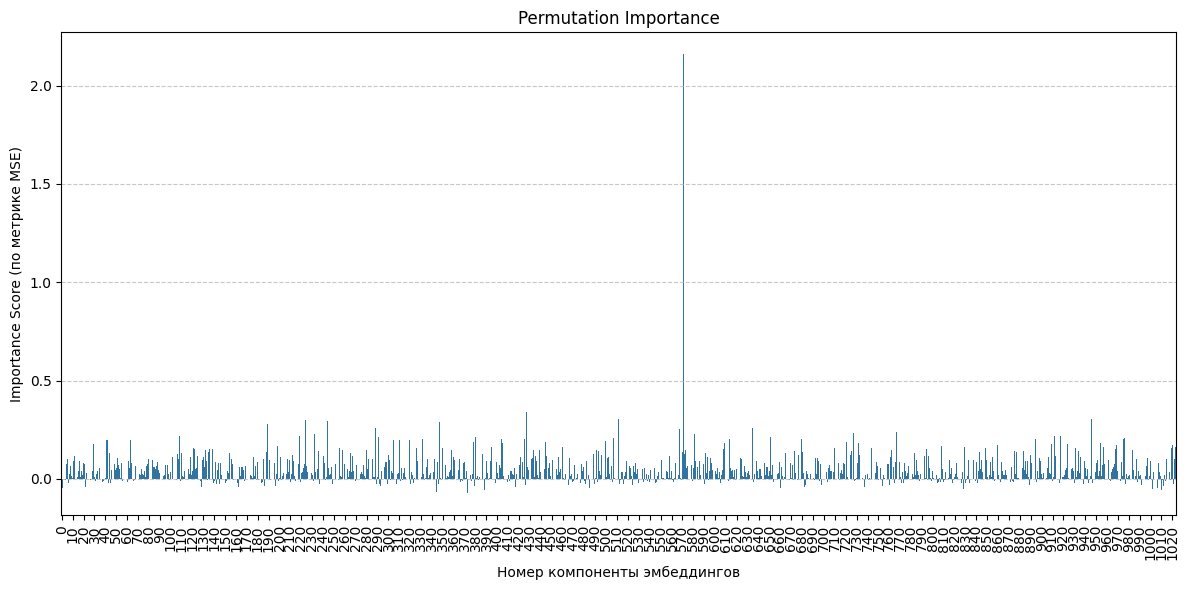

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_importance_scores(importance_scores, title='Permutation Importance', figsize=(12, 6)):
    plt.figure(figsize=figsize)
    sns.barplot(x=np.arange(len(importance_scores)), y=importance_scores)
    plt.title(title)
    plt.xlabel('Номер компоненты эмбеддингов')
    plt.ylabel('Importance Score (по метрике MSE)')

    plt.xticks(np.arange(0, len(importance_scores), 10), rotation=90)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_importance_scores(importance_raw)

In [ ]:
importance_raw[np.abs(importance_raw)<0.1].shape[0]

842

In [ ]:
corr_coeff = np.corrcoef(np.transpose(sample_dict_raw['test']))
np.abs(corr_coeff).min(), np.abs(np.tril(corr_coeff, k=-1)).max()

(np.float64(2.095591815427119e-06), np.float64(0.9760577359060755))

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Original embeddings shape: 1835
Projected embeddings shape: (1835, 2)


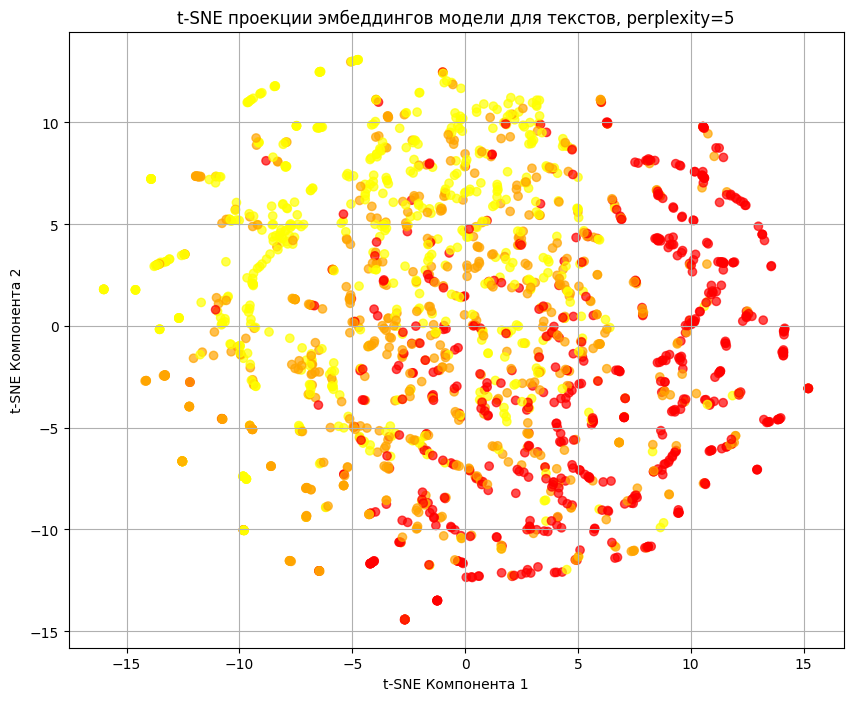

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Original embeddings shape: 1835
Projected embeddings shape: (1835, 2)


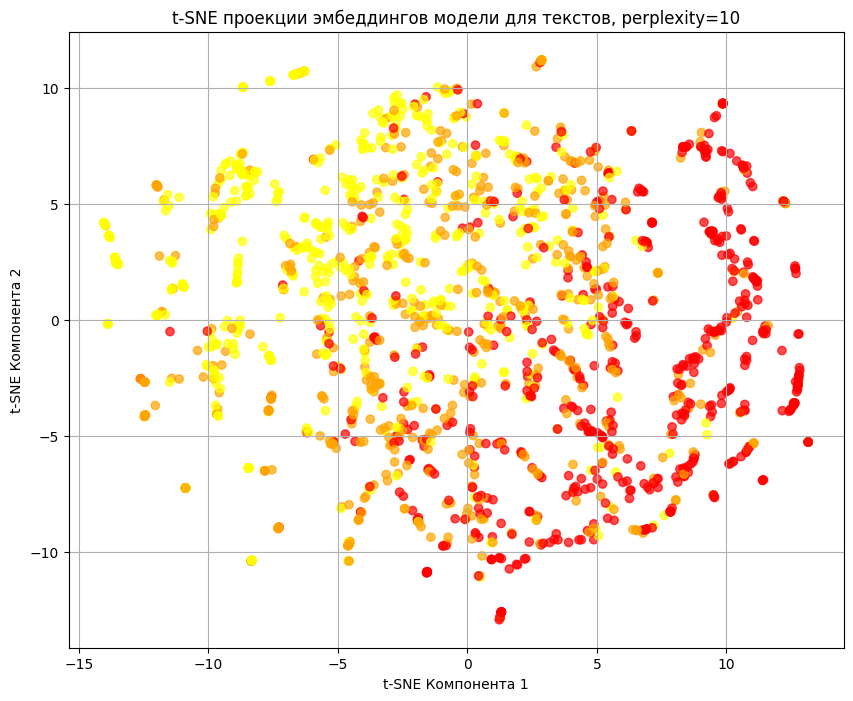

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Original embeddings shape: 1835
Projected embeddings shape: (1835, 2)


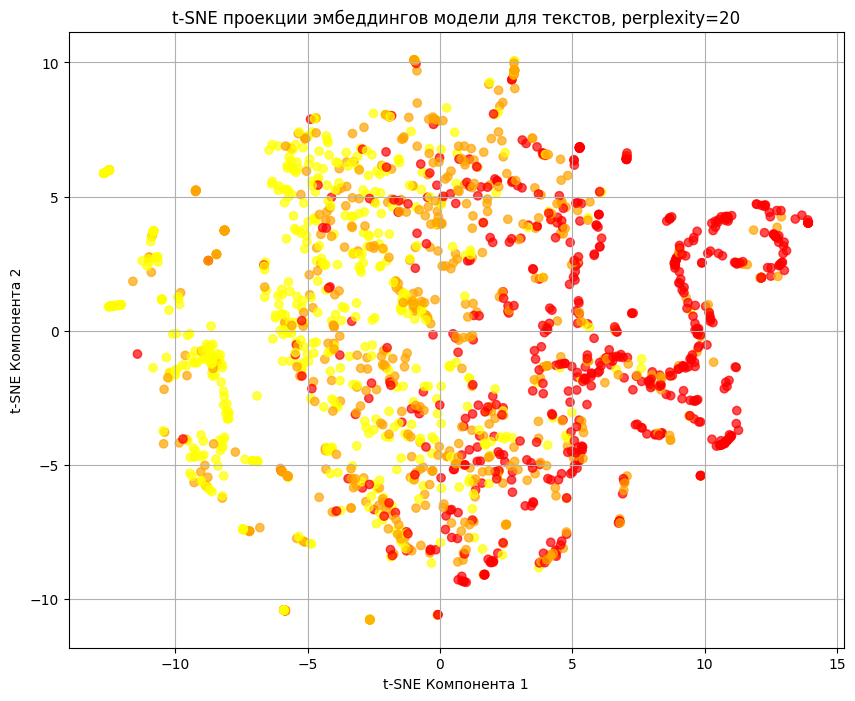

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Original embeddings shape: 1835
Projected embeddings shape: (1835, 2)


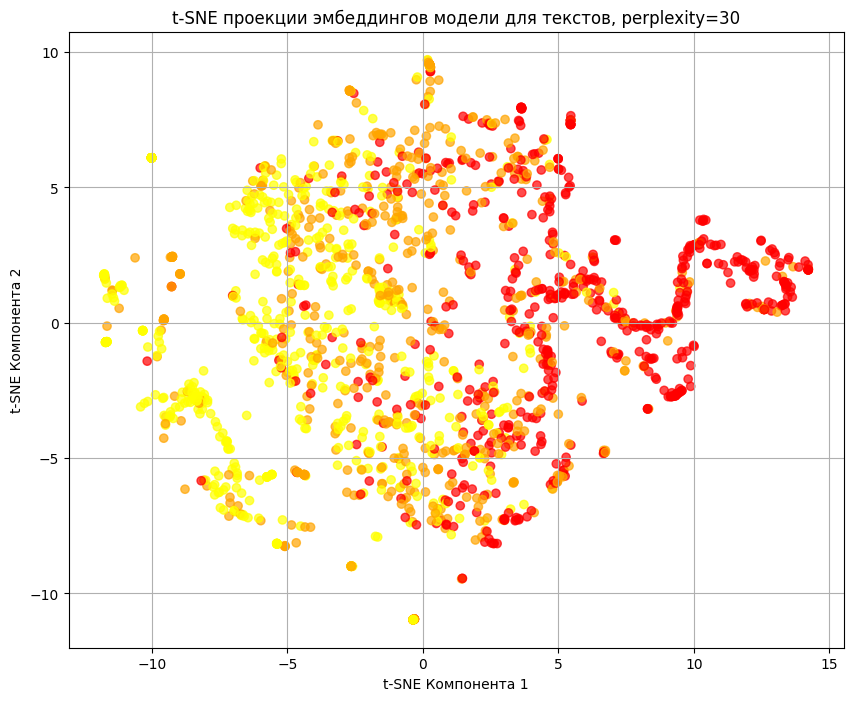

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Original embeddings shape: 1835
Projected embeddings shape: (1835, 2)


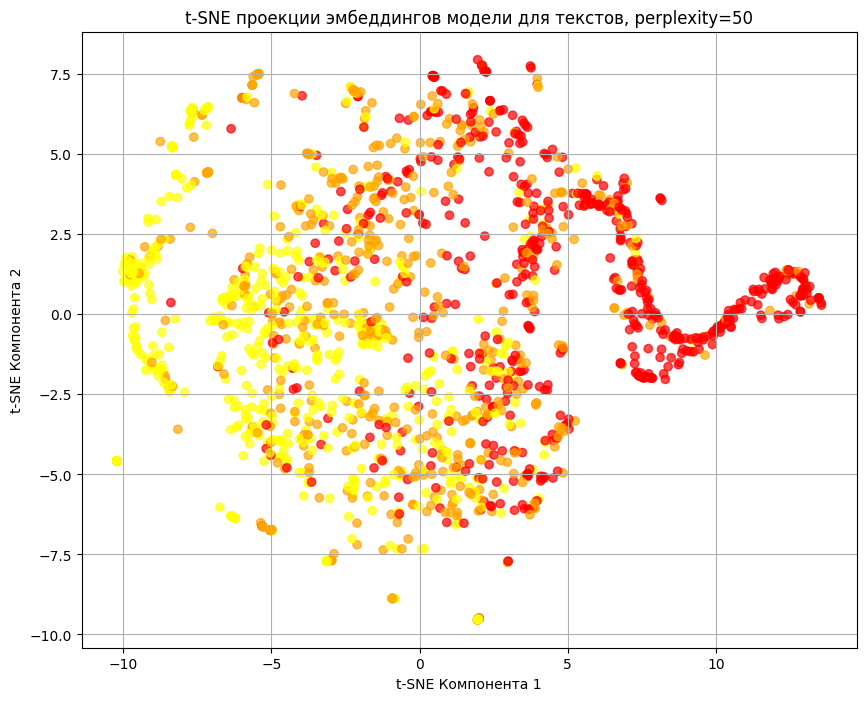

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Initialize t-SNE with 2 components for 2D visualization

for perpexity in [5, 10, 20, 30, 50]:

  tsne = TSNE(n_components=2, random_state=42, perplexity=perpexity, n_iter=300)

  # Fit t-SNE to the embeddings and transform them
  embeddings_2d = tsne.fit_transform(np.array(sample_dict_raw['test']))

  labels = pd.qcut(test_prices, q=3, labels=['yellow', 'orange', 'red'])

  print(f"Original embeddings shape: {len(sample_dict_raw['test'])}")
  print(f"Projected embeddings shape: {embeddings_2d.shape}")

  # Visualize the projected embeddings
  plt.figure(figsize=(10, 8))
  plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color=labels, alpha=0.7)
  plt.title(f't-SNE проекции эмбеддингов модели для текстов, perplexity={perpexity}')
  plt.xlabel('t-SNE Компонента 1')
  plt.ylabel('t-SNE Компонента 2')
  plt.grid(True)
  plt.show()

## Корреляционный анализ главных компонент эмбеддингов

In [ ]:
from sklearn.decomposition import PCA

# Initialize PCA to explain 80% of the variance
pca = PCA(n_components=0.9, random_state=42)

# Fit PCA to the embeddings and transform them
pca.fit(sample_dict_raw['train'])

embeddings_pca = pca.transform(sample_dict_raw['test'])

print(f"Original embeddings shape: {sample_dict_raw['test'].shape}")
print(f"Reduced embeddings shape (explaining 80% variance): {embeddings_pca.shape}")

Original embeddings shape: torch.Size([1835, 1024])
Reduced embeddings shape (explaining 80% variance): (1835, 7)


In [ ]:
pca.inverse_transform(embeddings_pca).shape

(1835, 1024)

In [ ]:
from scipy.stats import spearmanr, pearsonr

res=[]
for i in range(embeddings_pca.shape[1]):
  corr = spearmanr(embeddings_pca[:, i], test_prices)[0]
  res.append(corr)

In [ ]:
res

[np.float64(0.7392777971358527),
 np.float64(-0.36862490980348667),
 np.float64(-0.08177578388424794),
 np.float64(-0.021969523185635574),
 np.float64(0.09071389404773827),
 np.float64(0.1444084217855188),
 np.float64(-0.014034237550946304)]

## Абляционный анализ
Будем случайно заменять подмножетво компонент их средними.

Средние вычисляем на трейне

In [ ]:
train_averages = sample_dict_raw['train'].mean(axis=0)

In [ ]:
import torch.nn as nn
import numpy as np
import torch
from tqdm import tqdm

def ablation_study_function(model, data_array, target_array, train_averages, n_iterations=100, num_components_to_mask=100, random_state=42):
    np.random.seed(random_state)

    if not isinstance(data_array, torch.Tensor):
        data_array = torch.from_numpy(data_array).float()
    if not isinstance(target_array, torch.Tensor):
        target_array = torch.from_numpy(target_array).float().reshape(-1, 1)
    if not isinstance(train_averages, torch.Tensor):
        train_averages = torch.from_numpy(train_averages).float()

    model.eval()

    num_embedding_components = data_array.shape[1]
    ablation_metrics = []


    curr_avg_diff, prev_avg_diff = 0, -1

    with torch.no_grad():
      baseline_predictions = model(data_array)
      baseline_error = torch.mean((baseline_predictions - target_array)**2).item() # Using MSE as error

    for i in tqdm(range(n_iterations)):
        # Create a copy of the data to modify
        modified_data = data_array.clone()

        # Randomly select num_components_to_mask embedding component indices
        components_to_mask = np.random.choice(
            num_embedding_components,
            size=num_components_to_mask,
            replace=False
        )

        # Replace the selected components with their average values
        for comp_idx in components_to_mask:
            modified_data[:, comp_idx] = train_averages[comp_idx]

        # Calculate error with modified data
        with torch.no_grad():
            predictions = model(modified_data)
            error = torch.mean((predictions - target_array)**2).item() # Using MSE as error

        prev_avg_diff = curr_avg_diff
        rel_change = np.abs(error-baseline_error)/baseline_error
        curr_avg_diff = rel_change if i == 0 else (rel_change+prev_avg_diff*i)/(i+1)


        ablation_metrics.append(error)

    if (prev_avg_diff-curr_avg_diff) < 1e-4:
      print('Среднее сошлось!')

    ablation_metrics = np.array(ablation_metrics)
    print(f'Среднее относительное изменение {(np.abs(ablation_metrics - baseline_error)/baseline_error).mean()*100: .3f}')
    return ablation_metrics, ablation_metrics - baseline_error, baseline_error

In [ ]:
ablation_results = ablation_study_function(model_raw, sample_dict_raw['val'],val_prices, train_averages, n_iterations=200,
                                           num_components_to_mask=400)

100%|██████████| 200/200 [00:09<00:00, 21.63it/s]

Среднее сошлось!
Среднее относительное изменение  4.903


In [ ]:
ablation_results[2]

973.8051147460938

In [ ]:
sample_dict_raw['train']

tensor([[-0.0421,  0.4114,  0.3412,  ...,  0.1614,  0.7040,  0.9109],
        [-0.2266, -0.1928,  0.7162,  ...,  0.3127,  0.6451,  0.4447],
        [ 0.1632,  0.5333,  0.1220,  ...,  0.7697,  0.3361,  0.3506],
        ...,
        [ 0.0079,  0.0591,  0.3966,  ...,  0.2172,  0.6902,  0.9788],
        [-0.4888, -0.0214,  0.7955,  ...,  0.2788,  0.7818,  0.6586],
        [-0.3993, -0.6407,  0.7666,  ...,  0.2021,  1.0332,  0.6450]])

In [ ]:
#!rm -r '/content/ruenRoSBERTa_finetuned_pooler_embeddings'

In [ ]:
ablation_results = ablation_study_function(model_raw, sample_dict_raw['test'],test_prices, train_averages, n_iterations=200,
                                           num_components_to_mask=400)

100%|██████████| 200/200 [00:10<00:00, 19.22it/s]

Среднее сошлось!
Среднее относительное изменение  4.727


In [ ]:
ablation_results[2] # похоже на переобучение

1394.6676025390625

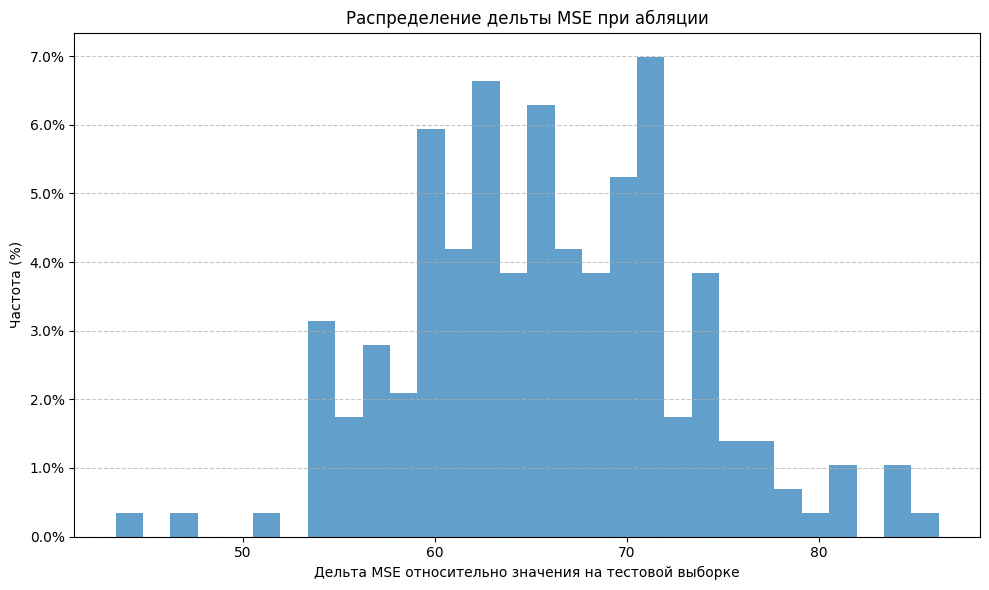

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(10, 6))
plt.hist(ablation_results[1], bins=30, density=True, alpha=0.7)

# Set y-axis to display frequency as percentages
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))

plt.title('Распределение дельты MSE при абляции')
plt.xlabel('Дельта MSE относительно значения на тестовой выборке')
plt.ylabel('Частота (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
с= ablation_study_function(model_raw, sample_dict_raw['test'],test_prices, train_averages, n_iterations=200,
                                           num_components_to_mask=250)

100%|██████████| 200/200 [00:16<00:00, 12.07it/s]

Среднее относительное изменение  19.389


In [ ]:
9

9

# Task
Create a new code cell to conduct an ablation study. Iterate through percentages from 5% to 100% (with a 5% step) to mask embedding components. For each percentage, calculate the number of components to mask, run the `ablation_study_function` on `sample_dict_raw['test']` with `test_prices` and `train_averages` (using 200 iterations), and store the average relative change in MSE. Finally, plot the relationship between the percentage of ablated coordinates and the average relative change in MSE.

## Implement Ablation Study Iteration and Plotting

### Subtask:
Perform an ablation study by iterating through various percentages of embedding components to mask, calculating the average relative change in MSE for each, and then plotting the results.


Running ablation study for 5% masking (51 components)...


100%|██████████| 200/200 [00:06<00:00, 33.21it/s]


Среднее сошлось!
Среднее относительное изменение  0.196
Running ablation study for 10% masking (102 components)...


100%|██████████| 200/200 [00:05<00:00, 38.25it/s]


Среднее сошлось!
Среднее относительное изменение  0.477
Running ablation study for 15% masking (153 components)...


...

Среднее сошлось!
Среднее относительное изменение  32.488
Running ablation study for 95% masking (972 components)...


100%|██████████| 200/200 [00:12<00:00, 16.22it/s]


Среднее сошлось!
Среднее относительное изменение  36.660
Running ablation study for 100% masking (1024 components)...


100%|██████████| 200/200 [00:12<00:00, 15.75it/s]


Среднее сошлось!
Среднее относительное изменение  40.964


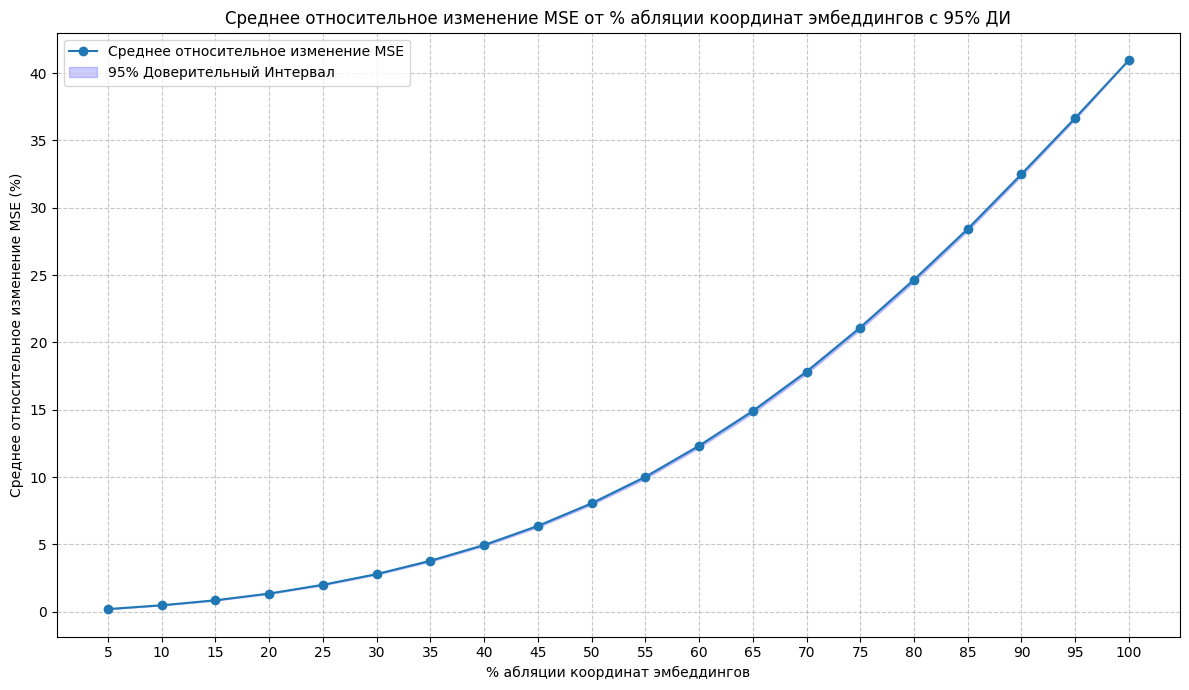

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats # For t-distribution critical value if needed, but z-score is fine for n=200

percentages = list(range(5, 101, 5))
all_ablation_results = [] # To store individual relative changes for CI calculation

num_total_components = sample_dict_raw['test'].shape[1]

for p in percentages:
    num_components_to_mask = int(num_total_components * (p / 100))
    print(f"Running ablation study for {p}% masking ({num_components_to_mask} components)...")

    # Call ablation_study_function once
    ablation_metrics, diffs, baseline_error = ablation_study_function(
        model_raw,
        sample_dict_raw['test'],
        test_prices,
        train_averages,
        n_iterations=200,
        num_components_to_mask=num_components_to_mask
    )

    # Calculate individual relative changes for each iteration
    relative_changes_per_iter = (np.abs(ablation_metrics - baseline_error) / baseline_error) * 100

    for change in relative_changes_per_iter:
        all_ablation_results.append({
            'percentage_ablated': p,
            'relative_mse_change': change
        })

# Convert to DataFrame for easier plotting with seaborn
df_ablation = pd.DataFrame(all_ablation_results)

# Calculate mean and standard error for plotting confidence intervals manually
summary_stats = df_ablation.groupby('percentage_ablated')['relative_mse_change'].agg(
    mean='mean',
    std='std',
    count='count'
).reset_index()

# Calculate Standard Error of the Mean (SEM)
summary_stats['sem'] = summary_stats['std'] / np.sqrt(summary_stats['count'])

# For 95% confidence interval, z-score is approximately 1.96 (for large N)
# Or t-score for df = count - 1 if using t-distribution
z_score = 1.96 # For 95% confidence

summary_stats['ci_lower'] = summary_stats['mean'] - z_score * summary_stats['sem']
summary_stats['ci_upper'] = summary_stats['mean'] + z_score * summary_stats['sem']

# Plotting the results manually with confidence intervals
plt.figure(figsize=(12, 7))
plt.plot(summary_stats['percentage_ablated'], summary_stats['mean'], marker='o', label='Среднее относительное изменение MSE')
plt.fill_between(
    summary_stats['percentage_ablated'],
    summary_stats['ci_lower'],
    summary_stats['ci_upper'],
    color='blue', alpha=0.2, label='95% Доверительный Интервал'
)

plt.title('Среднее относительное изменение MSE от % абляции координат эмбеддингов с 95% ДИ')
plt.xlabel('% абляции координат эмбеддингов')
plt.ylabel('Среднее относительное изменение MSE (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(percentages) # Ensure all percentages are shown on x-axis
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
summary_stats

,percentage_ablated,mean,std,count,sem,ci_lower,ci_upper
0,5,0.195902,0.060596,200,0.004285,0.187504,0.204300
1,10,0.477263,0.105954,200,0.007492,0.462578,0.491947
2,15,0.846866,0.156257,200,0.011049,0.825210,0.868522
3,20,1.347008,0.206771,200,0.014621,1.318351,1.375665
4,25,1.998072,0.275151,200,0.019456,1.959938,2.036206
5,30,2.790181,0.362004,200,0.025598,2.740010,2.840352
6,35,3.780187,0.440020,200,0.031114,3.719204,3.841171
7,40,4.947369,0.536579,200,0.037942,4.873002,5.021735
8,45,6.364322,0.656146,200,0.046397,6.273385,6.455259
9,50,8.042317,0.735472,200,0.052006,7.940386,8.144248


## Summary:

### Data Analysis Key Findings
*   An ablation study was performed by systematically masking a percentage of embedding components, ranging from 5% to 100% in 5% increments.
*   For each masking percentage, the `ablation_study_function` was executed using `sample_dict_raw['test']`, `test_prices`, and `train_averages`, with 200 iterations to ensure robust measurement.
*   The key metric recorded for each percentage was the average relative change in Mean Squared Error (MSE), which quantifies the impact of ablating components on prediction accuracy.
*   The results of the study were then plotted to visualize the relationship between the percentage of ablated coordinates and the average relative change in MSE.

### Insights or Next Steps
*   The implemented ablation study provides a framework to understand the sensitivity of the model to its embedding components.
*   The next crucial step is to analyze the generated plot and numerical results to identify specific thresholds or patterns in how masking components affects the model's performance, particularly its MSE.
